# Multimodal Price Prediction


## CELL 1 — Install Dependencies

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

install('git+https://github.com/openai/CLIP.git')
install('ftfy')
install('regex')

print('All dependencies installed.')

All dependencies installed.


## CELL 2 — Imports

In [2]:
import os, re, io, json, time, hashlib, warnings, requests
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader, TensorDataset

import clip
from PIL import Image, UnidentifiedImageError

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import joblib
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


## CELL 3 — Configuration

In [4]:
TRAIN_CSV   = '/kaggle/input/datasets/raghavdharwal/amazon-ml-challenge-2025/student_resource/dataset/train.csv'
TEST_CSV    = '/kaggle/input/datasets/raghavdharwal/amazon-ml-challenge-2025/student_resource/dataset/test.csv'
OUTPUT_DIR  = '/kaggle/working'
CACHE_DIR   = '/kaggle/working/emb_cache'  
MODEL_PATH  = '/kaggle/working/best_model.pt'
SUBMIT_PATH = '/kaggle/working/submission.csv'

TRAIN_SIZE  = 50_000    

HIDDEN_DIM  = 256
N_BLOCKS    = 5        
DROPOUT     = 0.2
EPOCHS      = 40
BATCH_SIZE  = 128
LR          = 1e-3
WEIGHT_DECAY= 1e-4
WARMUP_RATIO= 0.05
PATIENCE    = 7         
GRAD_CLIP   = 1.0
SEED        = 42


CLIP_MODEL  = 'ViT-B/16'
EMBED_DIM   = 512
CLIP_BATCH  = 16
USE_IMAGES  = True      


N_TOPICS    = 10

Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'USE_IMAGES = {USE_IMAGES}')
print('Config ready.')

Device : cuda
USE_IMAGES = True
Config ready.


## CELL 4 — Load & Split Data

In [5]:
print('Loading data...')
full_train = pd.read_csv(TRAIN_CSV)
test_df    = pd.read_csv(TEST_CSV) if Path(TEST_CSV).exists() else None

print(f'Full train shape : {full_train.shape}')
print(f'Columns          : {full_train.columns.tolist()}')
print(f'Sample rows      :')
display(full_train.head(3))


assert 'catalog_content' in full_train.columns, "Missing column: catalog_content"
assert 'price'           in full_train.columns, "Missing column: price"
assert 'image_link'      in full_train.columns, "Missing column: image_link"
assert 'sample_id'       in full_train.columns, "Missing column: sample_id"


full_train = full_train.dropna(subset=['price']).reset_index(drop=True)
print(f'\nAfter dropping NaN prices: {len(full_train):,} rows')


train_df = full_train.iloc[:TRAIN_SIZE].reset_index(drop=True)
val_df   = full_train.iloc[TRAIN_SIZE:].reset_index(drop=True)

print(f'\nTrain set : {len(train_df):,} rows')
print(f'Val set   : {len(val_df):,} rows  ← SMAPE evaluated here')
if test_df is not None:
    print(f'Test set  : {len(test_df):,} rows  ← final submission')

Loading data...
Full train shape : (75000, 4)
Columns          : ['sample_id', 'catalog_content', 'image_link', 'price']
Sample rows      :


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97



After dropping NaN prices: 75,000 rows

Train set : 50,000 rows
Val set   : 25,000 rows  ← SMAPE evaluated here
Test set  : 75,000 rows  ← final submission


## CELL 5 — Text Preprocessing & Feature Engineering

In [6]:
UNIT_MAP = {
    'kilogram':'kg','kilograms':'kg','kgs':'kg',
    'gram':'g','grams':'g','gm':'g','gms':'g',
    'milligram':'mg','milligrams':'mg',
    'pound':'lb','pounds':'lb','lbs':'lb',
    'ounce':'oz','ounces':'oz',
    'litre':'l','litres':'l','liter':'l','liters':'l',
    'millilitre':'ml','millilitres':'ml','milliliter':'ml',
    'fluid ounce':'fl oz','fluid ounces':'fl oz',
    'piece':'pc','pieces':'pc','pcs':'pc',
    'count':'ct','counts':'ct','pack':'pk','packs':'pk',
    'set':'set','sets':'set',
}
BRAND_KEYWORDS = [
    'samsung','apple','sony','lg','hp','dell','lenovo','asus','bosch',
    'philips','whirlpool','havells','bajaj','prestige','milton','amul',
    'nestle','britannia','patanjali','himalaya','dabur','colgate',
]
QUALITY_KEYWORDS = [
    'organic','premium','natural','original','authentic',
    'pure','fresh','raw','refined','whole','extra virgin',
]
PACK_RE = re.compile(
    r'(\d+(?:\.\d+)?)\s*'
    r'(kg|g|gm|gms|gram|grams|kilogram|kilograms|kgs'
    r'|ml|l|litre|litres|liter|liters|millilitre|millilitres'
    r'|lb|lbs|oz|fl\s*oz|mg|pc|pcs|piece|pieces|count|ct'
    r'|pack|packs|pk|set|sets)',
    re.IGNORECASE,
)


def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower().strip()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def extract_brand(text):
    if not isinstance(text, str): return 'unknown'
    tl = text.lower()
    for b in BRAND_KEYWORDS:
        if b in tl: return b
    tokens = text.split()
    if tokens and tokens[0][0].isupper(): return tokens[0].lower()
    return 'unknown'

def extract_pack_size(text):
    if not isinstance(text, str): return (np.nan, 'unknown')
    m = PACK_RE.findall(text)
    if m:
        qty, unit = m[0]
        unit = UNIT_MAP.get(unit.lower(), unit.lower())
        return (float(qty), unit)
    return (np.nan, 'unknown')

def normalize_to_grams(qty, unit):
    conv = {'kg':1000,'g':1,'mg':0.001,'lb':453.59,'oz':28.35}
    if pd.isna(qty): return np.nan
    return qty * conv.get(unit, 1)


def fit_lda(texts, n_topics=N_TOPICS):
    n_docs = len(texts)
    vec = CountVectorizer(
        max_features=5000, stop_words='english',
        min_df=min(5, max(1, int(n_docs * 0.01))),
        max_df=0.95,
    )
    X = vec.fit_transform(texts.fillna(''))
    lda = LatentDirichletAllocation(
        n_components=min(n_topics, n_docs),
        random_state=SEED, max_iter=20, learning_method='online',
    )
    lda.fit(X)
    return vec, lda

def transform_lda(texts, vec, lda):
    X = vec.transform(texts.fillna(''))
    tm = lda.transform(X)
    return pd.DataFrame(tm, index=texts.index,
                        columns=[f'lda_{i}' for i in range(tm.shape[1])])



def preprocess(df, fit=True, artifacts=None):
    """
    fit=True  : fit LDA + scaler (use on train set)
    fit=False : reuse fitted artifacts (use on val/test)
    Returns   : df_out, artifacts_dict
    """
    df = df.copy()

    
    df['combined_text']       = df['catalog_content'].fillna('')
    df['combined_text_clean'] = df['combined_text'].apply(clean_text)

    
    df['text_length']       = df['combined_text'].str.len().fillna(0)
    df['word_count']        = df['combined_text'].str.split().str.len().fillna(0)
    df['num_digits']        = df['combined_text'].apply(
                                  lambda t: sum(c.isdigit() for c in str(t)))
    df['num_special']       = df['combined_text'].apply(
                                  lambda t: sum(not c.isalnum() and not c.isspace()
                                               for c in str(t)))

   
    df['brand'] = df['combined_text'].apply(extract_brand)

    
    pack = df['combined_text'].apply(lambda t: pd.Series(extract_pack_size(t)))
    df['raw_qty']  = pack[0]
    df['unit']     = pack[1]
    df['norm_qty'] = df.apply(lambda r: normalize_to_grams(r['raw_qty'], r['unit']), axis=1)


    for kw in QUALITY_KEYWORDS:
        col = 'flag_' + kw.replace(' ', '_')
        df[col] = df['combined_text_clean'].str.contains(kw, case=False, na=False).astype(int)


    if fit:
        vec, lda = fit_lda(df['combined_text_clean'])
        artifacts = artifacts or {}
        artifacts['lda_vec'] = vec
        artifacts['lda_model'] = lda
    else:
        vec  = artifacts['lda_vec']
        lda  = artifacts['lda_model']

    lda_df = transform_lda(df['combined_text_clean'], vec, lda)
    df = pd.concat([df, lda_df], axis=1)

  
    for col in ['brand', 'unit']:
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            artifacts[f'le_{col}'] = le
        else:
            le = artifacts[f'le_{col}']
            known = set(le.classes_)
            df[col] = df[col].astype(str).apply(
                lambda x: x if x in known else le.classes_[0])
            df[col] = le.transform(df[col])


    num_cols = ['text_length','word_count','num_digits','num_special','norm_qty']
    df[num_cols] = df[num_cols].fillna(0)

    return df, artifacts

print('Preprocessing functions defined.')

Preprocessing functions defined.


## CELL 6 — CLIP Embedding Functions

In [7]:

_clip_model, _clip_preproc = None, None

def get_clip():
    global _clip_model, _clip_preproc
    if _clip_model is None:
        print(f'  Loading CLIP {CLIP_MODEL}...')
        _clip_model, _clip_preproc = clip.load(CLIP_MODEL, device=DEVICE)
        _clip_model.eval()
        print('  CLIP loaded.')
    return _clip_model, _clip_preproc

def cache_path(key):
    h = hashlib.md5(key.encode()).hexdigest()
    return Path(CACHE_DIR) / f'{h}.npy'

def load_image_url(url, timeout=8):
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return Image.open(io.BytesIO(r.content)).convert('RGB')
    except Exception:
        return None

def blank_image():
    return Image.fromarray(np.full((224, 224, 3), 128, dtype=np.uint8))


@torch.no_grad()
def embed_texts(texts: List[str]) -> np.ndarray:
    model, _ = get_clip()
    results  = np.zeros((len(texts), EMBED_DIM), dtype=np.float32)
    uncached_idx, uncached_texts = [], []

    for i, t in enumerate(texts):
        cp = cache_path('t_' + str(t)[:200])
        if cp.exists():
            results[i] = np.load(cp)
        else:
            uncached_idx.append(i)
            uncached_texts.append(t)

    for start in range(0, len(uncached_texts), CLIP_BATCH):
        batch_t   = uncached_texts[start:start+CLIP_BATCH]
        batch_idx = uncached_idx[start:start+CLIP_BATCH]
        tokens    = clip.tokenize([t[:300] for t in batch_t], truncate=True).to(DEVICE)
        feats     = model.encode_text(tokens).float()
        feats     = F.normalize(feats, dim=-1).cpu().numpy()
        for j, (orig_i, text) in enumerate(zip(batch_idx, batch_t)):
            results[orig_i] = feats[j]
            np.save(cache_path('t_' + str(text)[:200]), feats[j])

    return results


@torch.no_grad()
def embed_images(urls: List[str]):
    model, preproc = get_clip()
    results   = np.zeros((len(urls), EMBED_DIM), dtype=np.float32)
    is_missing = np.zeros(len(urls), dtype=bool)
    uncached_idx, uncached_urls = [], []

    for i, url in enumerate(urls):
        cp = cache_path('i_' + str(url))
        if cp.exists():
            results[i] = np.load(cp)
        else:
            uncached_idx.append(i)
            uncached_urls.append(url)

    for start in range(0, len(uncached_urls), CLIP_BATCH):
        batch_urls = uncached_urls[start:start+CLIP_BATCH]
        batch_idx  = uncached_idx[start:start+CLIP_BATCH]
        pil_imgs, missing = [], []
        for url in batch_urls:
            img = load_image_url(url) if (isinstance(url,str) and url.startswith('http')) else None
            if img is None:
                pil_imgs.append(blank_image()); missing.append(True)
            else:
                pil_imgs.append(img); missing.append(False)

        tensors = torch.stack([preproc(im) for im in pil_imgs]).to(DEVICE)
        feats   = model.encode_image(tensors).float()
        feats   = F.normalize(feats, dim=-1).cpu().numpy()

        for j, (orig_i, url, m) in enumerate(zip(batch_idx, batch_urls, missing)):
            if m:
                is_missing[orig_i] = True
                results[orig_i]    = np.zeros(EMBED_DIM)
            else:
                results[orig_i] = feats[j]
                np.save(cache_path('i_' + str(url)), feats[j])

    return results, is_missing


def build_embeddings(df):
    texts = df['combined_text_clean'].fillna('').tolist()
    print(f'  Embedding {len(texts)} texts...')
    t_embs = embed_texts(texts)

    if USE_IMAGES and 'image_link' in df.columns:
        urls = df['image_link'].fillna('').tolist()
        print(f'  Embedding {len(urls)} images (may take a while)...')
        i_embs, missing = embed_images(urls)
    else:
        i_embs  = np.zeros((len(df), EMBED_DIM), dtype=np.float32)
        missing = np.ones(len(df), dtype=bool)

   
    sim = np.einsum('ij,ij->i', t_embs, i_embs).astype(np.float32)

    t_cols = [f'te_{i}' for i in range(EMBED_DIM)]
    i_cols = [f'ie_{i}' for i in range(EMBED_DIM)]
    df_t   = pd.DataFrame(t_embs, index=df.index, columns=t_cols)
    df_i   = pd.DataFrame(i_embs, index=df.index, columns=i_cols)
    df     = df.copy()
    df['img_missing']  = missing.astype(int)
    df['text_img_sim'] = sim
    df = pd.concat([df, df_t, df_i], axis=1)
    return df

print('CLIP embedding functions defined.')

CLIP embedding functions defined.


## CELL 7 — Feature Fusion & Target Engineering

In [8]:
STRUCT_COLS = [
    'text_length', 'word_count', 'num_digits', 'num_special',
    'brand', 'unit', 'norm_qty', 'text_img_sim', 'img_missing',
]
TEXT_EMB_COLS = [f'te_{i}' for i in range(EMBED_DIM)]
IMG_EMB_COLS  = [f'ie_{i}' for i in range(EMBED_DIM)]

def get_struct_cols(df):
    lda_cols  = sorted([c for c in df.columns if c.startswith('lda_')])
    flag_cols = sorted([c for c in df.columns if c.startswith('flag_')])
    return [c for c in STRUCT_COLS + lda_cols + flag_cols if c in df.columns]

def fuse_features(df, scaler=None, struct_cols=None, fit=False):
    if struct_cols is None:
        struct_cols = get_struct_cols(df)

    X_struct = df[struct_cols].fillna(0).values.astype(np.float32)
    if fit or scaler is None:
        scaler   = StandardScaler().fit(X_struct)
    X_struct = scaler.transform(X_struct)

    t_cols = [c for c in TEXT_EMB_COLS if c in df.columns]
    i_cols = [c for c in IMG_EMB_COLS  if c in df.columns]
    X_text = df[t_cols].fillna(0).values.astype(np.float32) if t_cols \
             else np.zeros((len(df), EMBED_DIM), dtype=np.float32)
    X_img  = df[i_cols].fillna(0).values.astype(np.float32) if i_cols \
             else np.zeros((len(df), EMBED_DIM), dtype=np.float32)

    X = np.concatenate([X_struct, X_text, X_img], axis=1)
    print(f'  Feature matrix: {X.shape}  '
          f'[struct={X_struct.shape[1]}, text_emb={X_text.shape[1]}, img_emb={X_img.shape[1]}]')
    return X, scaler, struct_cols

def prepare_target(df):
    y = pd.to_numeric(df['price'], errors='coerce').clip(lower=1).fillna(1)
    return np.log1p(y.values).astype(np.float32)

def inv_target(y_log):
    return np.expm1(y_log)

print('Feature fusion functions defined.')

Feature fusion functions defined.


## CELL 8 — Model Architecture

In [9]:
class ResidualBlock(nn.Module):
    """Pre-activation residual block: LN → Linear → GELU → Dropout → Linear → + skip"""
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.ln1  = nn.LayerNorm(dim)
        self.fc1  = nn.Linear(dim, dim)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.ln2  = nn.LayerNorm(dim)
        self.fc2  = nn.Linear(dim, dim)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        r = x
        x = self.ln1(x)
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.ln2(x)
        x = self.fc2(x)
        return x + r


class DeepResidualMLP(nn.Module):
    """
    14-layer Deep Residual MLP
    Input → Projection(1) → ResBlock×5(10) → Bottleneck(1) → Head(1) → 13 + LN = ~14
    """
    def __init__(self, input_dim, hidden_dim=512, n_blocks=5, dropout=0.2):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        self.blocks = nn.ModuleList(
            [ResidualBlock(hidden_dim, dropout) for _ in range(n_blocks)]
        )
        bot_dim = hidden_dim // 2
        self.bottleneck = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, bot_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.LayerNorm(bot_dim),
            nn.Linear(bot_dim, 1),
        )
        nn.init.xavier_uniform_(self.proj[0].weight)
        nn.init.xavier_uniform_(self.bottleneck[1].weight)
        nn.init.xavier_uniform_(self.head[1].weight)

    def forward(self, x):
        x = self.proj(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.bottleneck(x)
        return self.head(x).squeeze(-1)


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Symmetric Mean Absolute Percentage Error — official competition metric."""
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.maximum(np.array(y_pred, dtype=np.float64), 0.01)
    num  = np.abs(y_pred - y_true)
    den  = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return float(np.mean(num / (den + 1e-8)) * 100)


print('Model architecture defined.')
print(f'  ResidualBlock + DeepResidualMLP ready.')
print(f'  SMAPE metric function ready.')

Model architecture defined.
  ResidualBlock + DeepResidualMLP ready.
  SMAPE metric function ready.


## CELL 9 — Training & Evaluation Loop

In [10]:
def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.from_numpy(X).float(),
                       torch.from_numpy(y).float())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE=='cuda'))

def make_pred_loader(X, batch_size=512):
    ds = TensorDataset(torch.from_numpy(X).float())
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        total += loss.item() * len(yb)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    preds, trues, total = [], [], 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        p = model(Xb)
        total += criterion(p, yb).item() * len(yb)
        preds.append(p.cpu().numpy())
        trues.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)

    
    pred_price = inv_target(preds).clip(min=0.01)
    true_price = inv_target(trues)
    val_smape  = smape(true_price, pred_price)
    val_loss   = total / len(loader.dataset)
    return val_loss, val_smape, preds, trues

@torch.no_grad()
def predict(model, X):
    model.eval()
    loader = make_pred_loader(X)
    preds  = []
    for (Xb,) in loader:
        preds.append(model(Xb.to(DEVICE)).cpu().numpy())
    log_preds = np.concatenate(preds)
    return inv_target(log_preds).clip(min=0.01)

print('Training loop functions defined.')

Training loop functions defined.


## CELL 10 — Full Pipeline: Preprocess + Embed + Fuse

In [11]:
import gc

def process_in_chunks(df, chunk_size=5000, fit=True, artifacts=None):
    
    n      = len(df)
    chunks = range(0, n, chunk_size)
    all_emb_paths = []

    for ci, start in enumerate(chunks):
        end   = min(start + chunk_size, n)
        chunk = df.iloc[start:end].reset_index(drop=True)
        print(f'  Chunk {ci+1}/{len(chunks)}: rows {start}–{end}')

        # preprocess
        if ci == 0 and fit:
            chunk_proc, artifacts = preprocess(chunk, fit=True,  artifacts=artifacts)
        else:
            chunk_proc, _         = preprocess(chunk, fit=False, artifacts=artifacts)

        # embed
        chunk_proc = build_embeddings(chunk_proc)

        # extract only the arrays we need — drop the full DataFrame
        struct_cols = artifacts.get('struct_cols') or get_struct_cols(chunk_proc)

        lda_cols  = sorted([c for c in chunk_proc.columns if c.startswith('lda_')])
        flag_cols = sorted([c for c in chunk_proc.columns if c.startswith('flag_')])
        s_cols    = [c for c in STRUCT_COLS + lda_cols + flag_cols
                     if c in chunk_proc.columns]

        X_s = chunk_proc[s_cols].fillna(0).values.astype(np.float32)
        t_c = [f'te_{i}' for i in range(EMBED_DIM) if f'te_{i}' in chunk_proc.columns]
        i_c = [f'ie_{i}' for i in range(EMBED_DIM) if f'ie_{i}' in chunk_proc.columns]
        X_t = chunk_proc[t_c].fillna(0).values.astype(np.float32) if t_c \
              else np.zeros((len(chunk), EMBED_DIM), dtype=np.float32)
        X_i = chunk_proc[i_c].fillna(0).values.astype(np.float32) if i_c \
              else np.zeros((len(chunk), EMBED_DIM), dtype=np.float32)

        # save chunk arrays to disk immediately
        chunk_path = f'{CACHE_DIR}/chunk_{ci}.npz'
        np.savez_compressed(chunk_path,
                            X_s=X_s, X_t=X_t, X_i=X_i)
        all_emb_paths.append((chunk_path, s_cols))

        if ci == 0 and fit:
            artifacts['struct_cols'] = s_cols

        # free memory
        del chunk_proc, chunk, X_s, X_t, X_i
        gc.collect()
        torch.cuda.empty_cache() if DEVICE == 'cuda' else None
        print(f'    Chunk {ci+1} done. Memory freed.')

    return all_emb_paths, artifacts


def load_and_fuse_chunks(chunk_paths, artifacts, fit_scaler_on_first=True):
    """Load saved chunks, fit scaler, return final X array."""
    from sklearn.preprocessing import StandardScaler

    
    all_Xs = []
    for path, _ in chunk_paths:
        d = np.load(path)
        all_Xs.append(d['X_s'])

    all_Xs_cat = np.concatenate(all_Xs, axis=0)

    if fit_scaler_on_first:
        scaler = StandardScaler().fit(all_Xs_cat)
        artifacts['scaler'] = scaler
    else:
        scaler = artifacts['scaler']

    del all_Xs, all_Xs_cat
    gc.collect()

   
    X_parts = []
    for path, _ in chunk_paths:
        d    = np.load(path)
        X_s  = scaler.transform(d['X_s'])
        X_t  = d['X_t']
        X_i  = d['X_i']
        X_parts.append(np.concatenate([X_s, X_t, X_i], axis=1).astype(np.float32))
        del d, X_s, X_t, X_i
        gc.collect()

    X = np.concatenate(X_parts, axis=0)
    del X_parts
    gc.collect()
    print(f'  Final feature matrix: {X.shape}')
    return X, artifacts


pipeline_artifacts = {}
print('='*60)
print('STEP 1/4 — Processing train set in chunks...')
train_chunk_paths, pipeline_artifacts = process_in_chunks(
    train_df, chunk_size=5000, fit=True, artifacts=pipeline_artifacts
)

print('\nSTEP 2/4 — Fusing train features...')
X_train, pipeline_artifacts = load_and_fuse_chunks(
    train_chunk_paths, pipeline_artifacts, fit_scaler_on_first=True
)
y_train = prepare_target(train_df)

print('\nSTEP 3/4 — Processing val set in chunks...')
val_chunk_paths, _ = process_in_chunks(
    val_df, chunk_size=5000, fit=False, artifacts=pipeline_artifacts
)

print('\nSTEP 4/4 — Fusing val features...')
X_val, _ = load_and_fuse_chunks(
    val_chunk_paths, pipeline_artifacts, fit_scaler_on_first=False
)
y_val = prepare_target(val_df)

import joblib
joblib.dump(pipeline_artifacts, f'{OUTPUT_DIR}/pipeline_artifacts.pkl')

print(f'\nX_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print('Pipeline complete.')

STEP 1/4 — Processing train set in chunks...
  Chunk 1/10: rows 0–5000
  Embedding 5000 texts...
  Loading CLIP ViT-B/16...
  CLIP loaded.
  Embedding 5000 images (may take a while)...
    Chunk 1 done. Memory freed.
  Chunk 2/10: rows 5000–10000
  Embedding 5000 texts...
  Embedding 5000 images (may take a while)...
    Chunk 2 done. Memory freed.
  Chunk 3/10: rows 10000–15000
  Embedding 5000 texts...
  Embedding 5000 images (may take a while)...
    Chunk 3 done. Memory freed.
  Chunk 4/10: rows 15000–20000
  Embedding 5000 texts...
  Embedding 5000 images (may take a while)...
    Chunk 4 done. Memory freed.
  Chunk 5/10: rows 20000–25000
  Embedding 5000 texts...
  Embedding 5000 images (may take a while)...
    Chunk 5 done. Memory freed.
  Chunk 6/10: rows 25000–30000
  Embedding 5000 texts...
  Embedding 5000 images (may take a while)...
    Chunk 6 done. Memory freed.
  Chunk 7/10: rows 30000–35000
  Embedding 5000 texts...
  Embedding 5000 images (may take a while)...
    Ch

## CELL 11 — Train the Model

In [12]:
input_dim = X_train.shape[1]
model     = DeepResidualMLP(
    input_dim  = input_dim,
    hidden_dim = HIDDEN_DIM,
    n_blocks   = N_BLOCKS,
    dropout    = DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model ready | input_dim={input_dim} | params={n_params:,} | device={DEVICE}')

criterion    = nn.HuberLoss(delta=1.0)
total_steps  = EPOCHS * (len(X_train) // BATCH_SIZE + 1)
warmup_steps = int(total_steps * WARMUP_RATIO)


decay, no_decay = [], []
for name, p in model.named_parameters():
    if p.requires_grad:
        (no_decay if ('bias' in name or 'ln' in name) else decay).append(p)
optimizer = torch.optim.AdamW(
    [{'params': decay, 'weight_decay': WEIGHT_DECAY},
     {'params': no_decay, 'weight_decay': 0.0}],
    lr=LR, betas=(0.9, 0.999), eps=1e-8,
)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    prog = float(step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + np.cos(np.pi * prog)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)


best_smape, patience_ctr = float('inf'), 0
history = []

print(f'\nTraining for up to {EPOCHS} epochs (early stop patience={PATIENCE})\n')
print(f'{"Epoch":>6} {"Train Loss":>12} {"Val Loss":>10} {"SMAPE %":>10}')
print('-' * 45)

for epoch in range(1, EPOCHS + 1):
    t_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    v_loss, v_smape, _, _ = evaluate(model, val_loader, criterion)

    history.append({'epoch': epoch, 'train_loss': t_loss,
                    'val_loss': v_loss, 'smape': v_smape})
    print(f'{epoch:>6}  {t_loss:>12.4f}  {v_loss:>10.4f}  {v_smape:>9.2f}%')

    if v_smape < best_smape:
        best_smape   = v_smape
        patience_ctr = 0
        torch.save({'state_dict': model.state_dict(),
                    'input_dim': input_dim,
                    'best_smape': best_smape,
                    'epoch': epoch}, MODEL_PATH)
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

print(f'\nBest validation SMAPE: {best_smape:.2f}%')
print(f'Model saved to: {MODEL_PATH}')

Model ready | input_dim=1054 | params=967,425 | device=cuda

Training for up to 40 epochs (early stop patience=7)

 Epoch   Train Loss   Val Loss    SMAPE %
---------------------------------------------
     1        0.5769      0.3175      65.75%
     2        0.2816      0.3222      66.54%
     3        0.2564      0.2586      58.93%
     4        0.2418      0.3088      64.39%
     5        0.2287      0.2680      60.38%
     6        0.2179      0.3207      65.75%
     7        0.2090      0.2888      61.99%
     8        0.1981      0.2695      59.70%
     9        0.1881      0.2504      56.29%
    10        0.1780      0.2450      56.20%
    11        0.1703      0.2423      55.24%
    12        0.1622      0.2481      56.03%
    13        0.1531      0.2745      59.18%
    14        0.1457      0.2681      57.44%
    15        0.1371      0.2431      54.30%
    16        0.1295      0.2567      55.79%
    17        0.1234      0.2490      54.65%
    18        0.1186      0.2611

## CELL 12 — Evaluate on Validation Set (Final SMAPE Score)

In [13]:
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['state_dict'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} | SMAPE={ckpt["best_smape"]:.2f}%')


val_preds_price = predict(model, X_val)
val_true_price  = inv_target(y_val)


final_smape = smape(val_true_price, val_preds_price)


abs_err  = np.abs(val_preds_price - val_true_price)
mape_val = np.mean(abs_err / (val_true_price + 1e-8)) * 100
rmse_val = np.sqrt(np.mean((val_preds_price - val_true_price) ** 2))
med_err  = np.median(abs_err)

print('\n' + '='*50)
print('  VALIDATION SET PERFORMANCE')
print('='*50)
print(f'  Samples evaluated : {len(val_true_price):,}')
print(f'  SMAPE             : {final_smape:.4f}% ')
print(f'  MAPE              : {mape_val:.4f}%')
print(f'  RMSE              : {rmse_val:.4f}')
print(f'  Median Abs Error  : {med_err:.4f}')
print('='*50)


print(f'\nTrue  price  — mean: {val_true_price.mean():.2f}  '
      f'median: {np.median(val_true_price):.2f}  '
      f'max: {val_true_price.max():.2f}')
print(f'Pred  price  — mean: {val_preds_price.mean():.2f}  '
      f'median: {np.median(val_preds_price):.2f}  '
      f'max: {val_preds_price.max():.2f}')

Loaded best checkpoint from epoch 20 | SMAPE=54.07%

  VALIDATION SET PERFORMANCE
  Samples evaluated : 25,000
  SMAPE             : 54.0653%   ← official metric
  MAPE              : 90.3253%
  RMSE              : 30.3030
  Median Abs Error  : 6.1893

True  price  — mean: 23.66  median: 14.00  max: 2796.00
Pred  price  — mean: 23.35  median: 14.93  max: 361.03


## CELL 13 — Save Validation Predictions

In [14]:

val_results = pd.DataFrame({
    'sample_id'    : val_df['sample_id'].values,
    'true_price'   : val_true_price,
    'pred_price'   : val_preds_price,
    'abs_error'    : np.abs(val_preds_price - val_true_price),
    'smape_row'    : (np.abs(val_preds_price - val_true_price) /
                      ((np.abs(val_true_price) + np.abs(val_preds_price)) / 2 + 1e-8)) * 100,
})

val_results_path = f'{OUTPUT_DIR}/validation_predictions.csv'
val_results.to_csv(val_results_path, index=False)
print(f'Validation predictions saved to: {val_results_path}')


Validation predictions saved to: /kaggle/working/validation_predictions.csv

Worst predictions (highest SMAPE):


,sample_id,true_price,pred_price,smape_row
21551,76938,155.989975,1.533475,196.106033
20289,294879,1.390000,101.670570,194.605118
5284,78050,1.000000,62.537811,193.704529
10786,215298,138.279999,2.367048,193.268112
17005,161862,2.690000,156.416046,193.237213
6172,162020,118.570023,2.142538,192.900360
6600,161248,279.679962,5.066950,192.882172
24622,276467,2.550000,140.402588,192.864761
1561,292721,1.000000,54.361164,192.774719
14894,168356,1.000000,54.172661,192.750031



Best predictions (lowest SMAPE):


,sample_id,true_price,pred_price,smape_row
22202,165360,3.500000,3.499609,0.011172
16415,271228,14.969999,14.968171,0.012213
13944,252707,19.990000,19.987303,0.013493
18858,13478,6.190000,6.191094,0.017670
660,62944,15.990000,15.993091,0.019328
17422,56793,7.119999,7.118611,0.019497
13610,40059,10.520000,10.522170,0.020631
14252,65805,79.970001,79.987030,0.021292
3956,123540,12.990001,12.987089,0.022416
16703,126186,5.835000,5.836415,0.024260


## CELL 14 — Predict on Test Set & Generate Submission

In [15]:
if test_df is not None:
    print('Processing test set for final submission...')

    test_proc, _ = preprocess(test_df, fit=False, artifacts=pipeline_artifacts)
    test_proc    = build_embeddings(test_proc)
    X_test, _, _ = fuse_features(test_proc,
                                  scaler=pipeline_artifacts['scaler'],
                                  struct_cols=pipeline_artifacts['struct_cols'],
                                  fit=False)

    test_preds = predict(model, X_test)

    submission = pd.DataFrame({
        'sample_id' : test_df['sample_id'].values,
        'price'     : test_preds,
    })
    submission.to_csv(SUBMIT_PATH, index=False)

    print(f'\nSubmission saved to: {SUBMIT_PATH}')
    print(f'Rows: {len(submission):,}')
    print(f'Price range: {submission["price"].min():.2f} — {submission["price"].max():.2f}')
    print(f'Mean price : {submission["price"].mean():.2f}')
    display(submission.head(10))
else:
    print('No test.csv found — skipping submission generation.')

Processing test set for final submission...
  Embedding 75000 texts...
  Embedding 75000 images (may take a while)...


KeyboardInterrupt: 

## CELL 15 — Training History Plot

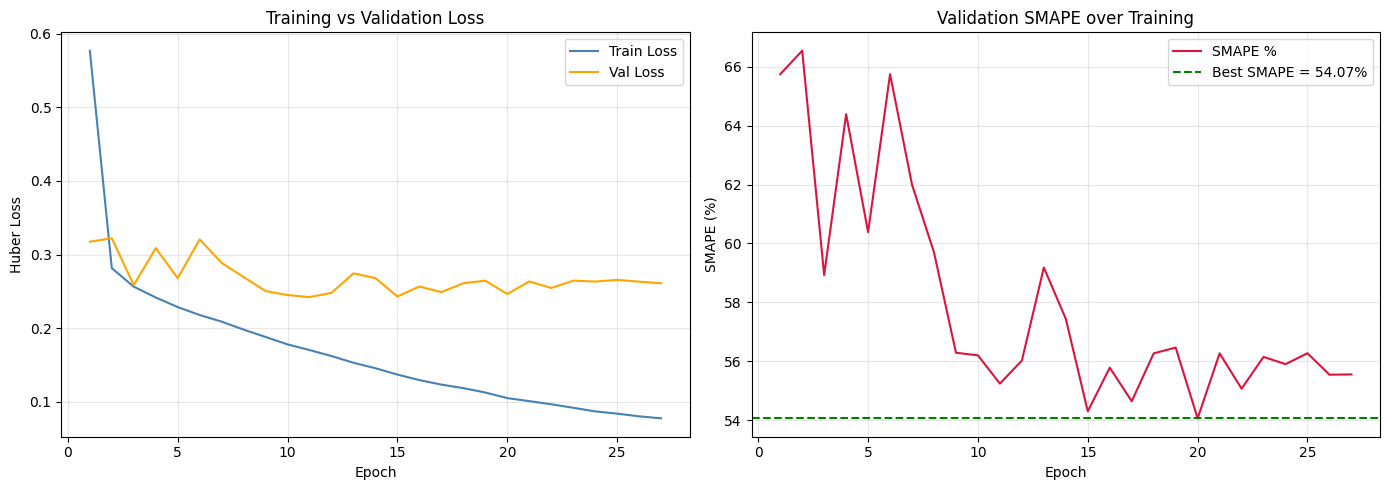

Plot saved to /kaggle/working/training_history.png


In [16]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_df['epoch'], hist_df['smape'], color='crimson', label='SMAPE %')
axes[1].axhline(y=best_smape, color='green', linestyle='--',
                label=f'Best SMAPE = {best_smape:.2f}%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('SMAPE (%)')
axes[1].set_title('Validation SMAPE over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {OUTPUT_DIR}/training_history.png')